# Multi-Head Attention

## Why Multiple Heads

Single attention head: one set of $Q, K, V$ projections $\rightarrow$ one "type" of similarity.

Multi-head: $h$ parallel attention heads, each with different learned projections. Each head can focus on different aspects (e.g., syntactic relationships in one head, semantic in another).

Formally:
- Input: $X \in \mathbb{R}^{n \times d_{\text{model}}}$
- For head $i$: $Q_i = XW_i^Q, \quad K_i = XW_i^K, \quad V_i = XW_i^V$
  - $W_i^Q \in \mathbb{R}^{d_{\text{model}} \times d_k}, \quad W_i^K \in \mathbb{R}^{d_{\text{model}} \times d_k}, \quad W_i^V \in \mathbb{R}^{d_{\text{model}} \times d_v}$
- $\text{head}_i = \text{Attention}(Q_i, K_i, V_i) \in \mathbb{R}^{n \times d_v}$
- $\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) \, W^O$
  - $\text{Concat} \in \mathbb{R}^{n \times (h \cdot d_v)}, \quad W^O \in \mathbb{R}^{(h \cdot d_v) \times d_{\text{model}}}$
  - Output $\in \mathbb{R}^{n \times d_{\text{model}}}$

Standard choice: $d_k = d_v = d_{\text{model}} / h$

## Parameter Count Analysis

Per head: $3 \times d_{\text{model}} \times d_k$ (for $W^Q, W^K, W^V$)

All heads:
$$h \times 3 \times d_{\text{model}} \times d_k = 3 \times d_{\text{model}} \times (h \times d_k) = 3 \times d_{\text{model}}^2 \quad \text{(if } d_k = d_{\text{model}}/h\text{)}$$

Output projection: $d_{\text{model}} \times d_{\text{model}} = d_{\text{model}}^2$

**Total: $4 \times d_{\text{model}}^2$** (without bias)

Same parameter count as a single head with $d_k = d_{\text{model}}$, but the multi-head version can attend to different representation subspaces.

## Computational Complexity

- Computing $QK^T$ for one head: $O(n \times m \times d_k)$
- All $h$ heads: $O(n \times m \times d_k \times h) = O(n \times m \times d_{\text{model}})$ : same as single head with full $d_{\text{model}}$
- The benefit is representational capacity

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Import attention from notebook 01 (or redefine)
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    weights = F.softmax(scores, dim=-1)
    return weights @ V, weights

## Implementation

Implement `MultiHeadAttention` as an `nn.Module`. Key design decisions:
- Store $W^Q, W^K, W^V$ as a single linear layer or separate ones (both valid)
- Efficient approach: project to full $d_{\text{model}}$, then reshape to `(batch, h, n, d_k)` for parallel attention
- Output projection $W^O$

In [2]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention mechanism.
    
    Args:
        d_model: model dimension (e.g., 512)
        n_heads: number of attention heads (e.g., 8)
    
    Shapes:
        Input:  (batch, seq_len, d_model)
        Output: (batch, seq_len, d_model)
    """
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads  # d_k = d_v = d_model / h
        
        # TODO: Create linear projections for Q, K, V (each: d_model -> d_model)
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # TODO: Create output projection W^O (d_model -> d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def forward(self, query, key, value, mask=None):
        """
        Args:
            query: (batch, n, d_model)
            key:   (batch, m, d_model)
            value: (batch, m, d_model)
            mask:  optional (batch, 1, 1, m) or (batch, 1, n, m)
        
        Returns:
            output: (batch, n, d_model)
            attention_weights: (batch, n_heads, n, m)
        """
        batch_size = query.size(0)
        
        # TODO: Project inputs through W_q, W_k, W_v
        # Shape after projection: (batch, seq_len, d_model)
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        # TODO: Reshape to (batch, n_heads, seq_len, d_k)
        # Hint: view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        Q = Q.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        # TODO: Apply scaled dot-product attention (use the function from notebook 01)
        # This works on the (batch, n_heads, seq_len, d_k) tensors directly
        # because attention treats the first two dims as batch dims
        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)

        # TODO: Reshape back: (batch, n_heads, n, d_k) -> (batch, n, d_model)
        # Hint: transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        # TODO: Apply output projection W^O
        output = self.W_o(attn_output)
        
        return output, attn_weights

## Verification

In [3]:
# Test dimensions
batch, n, m, d_model, n_heads = 2, 10, 10, 64, 8

mha = MultiHeadAttention(d_model, n_heads)
query = torch.randn(batch, n, d_model)
key = torch.randn(batch, m, d_model)
value = torch.randn(batch, m, d_model)

output, weights = mha(query, key, value)

print(f"Output shape: {output.shape}")       # (2, 10, 64)
print(f"Weights shape: {weights.shape}")     # (2, 8, 10, 10)

assert output.shape == (batch, n, d_model)
assert weights.shape == (batch, n_heads, n, m)

# Verify weights sum to 1 per query per head
assert torch.allclose(weights.sum(dim=-1), torch.ones(batch, n_heads, n), atol=1e-6)

# Compare against PyTorch's nn.MultiheadAttention
pytorch_mha = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
# Note: PyTorch uses different weight layout, so outputs won't match exactly,
# but shapes and properties should match
pt_output, pt_weights = pytorch_mha(query, key, value)
print(f"\nPyTorch output shape: {pt_output.shape}")   # Same: (2, 10, 64)
print(f"PyTorch weights shape: {pt_weights.shape}")   # (2, 10, 10) — averaged over heads

# Count parameters
total_params = sum(p.numel() for p in mha.parameters())
expected_params = 4 * d_model * d_model  # 3 projections + output = 4 * d_model^2
print(f"\nTotal parameters: {total_params}")
print(f"Expected (4 * d_model^2): {expected_params}")
# Note: +4*d_model if using bias in linear layers

print("\n\u2713 All checks passed!")

Output shape: torch.Size([2, 10, 64])
Weights shape: torch.Size([2, 8, 10, 10])

PyTorch output shape: torch.Size([2, 10, 64])
PyTorch weights shape: torch.Size([2, 10, 10])

Total parameters: 16640
Expected (4 * d_model^2): 16384

✓ All checks passed!


## Experiment: What Do Different Heads Learn?

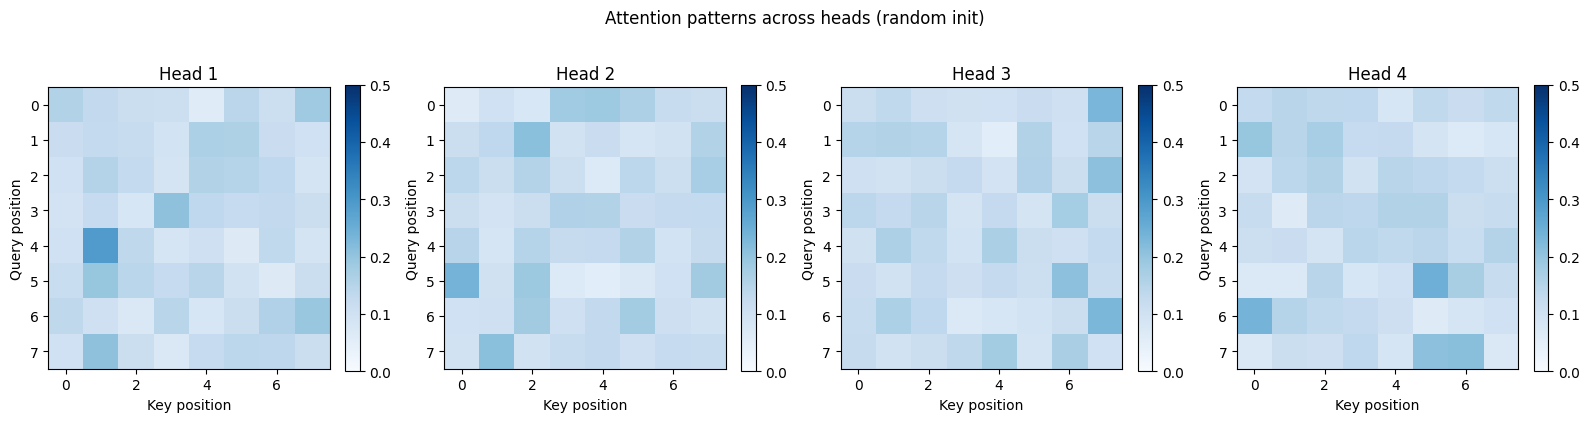

In [4]:
# Create a sequence with clear structure for heads to specialize on
seq_len = 8
d_model = 64
n_heads = 4

mha = MultiHeadAttention(d_model, n_heads)

# Random "sentence" embedding
x = torch.randn(1, seq_len, d_model)

# Self-attention (Q = K = V = X)
_, weights = mha(x, x, x)

fig, axes = plt.subplots(1, n_heads, figsize=(4 * n_heads, 4))
for h in range(n_heads):
    ax = axes[h]
    im = ax.imshow(weights[0, h].detach().numpy(), cmap='Blues', vmin=0, vmax=0.5)
    ax.set_title(f'Head {h+1}')
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Attention patterns across heads (random init)', y=1.02)
plt.tight_layout()
plt.show()

# At initialization: heads look similar (random projections).
# After training, heads specialize — some attend locally, some globally,
# some to specific syntactic roles.

## Self-Attention vs Cross-Attention

**Self-attention:** $Q = K = V$ are all derived from the same sequence $X$.
- Used in encoder (BERT) and decoder masked self-attention (GPT).

**Cross-attention:** $Q$ from one sequence, $K$ and $V$ from another.
- Used in encoder-decoder models: $Q$ from decoder, $K/V$ from encoder output.
- Your `MultiHeadAttention` already supports this — just pass different tensors for `query` vs `key`/`value`.

In [5]:
# Self-attention vs cross-attention demo
encoder_out = torch.randn(1, 6, d_model)  # encoder output (source)
decoder_in = torch.randn(1, 4, d_model)   # decoder input (target)

mha = MultiHeadAttention(d_model, n_heads=4)

# Self-attention: encoder attends to itself
self_out, self_weights = mha(encoder_out, encoder_out, encoder_out)
print(f"Self-attention output: {self_out.shape}")        # (1, 6, 64)
print(f"Self-attention weights: {self_weights.shape}")   # (1, 4, 6, 6)

# Cross-attention: decoder queries attend to encoder keys/values
cross_out, cross_weights = mha(decoder_in, encoder_out, encoder_out)
print(f"Cross-attention output: {cross_out.shape}")      # (1, 4, 64)
print(f"Cross-attention weights: {cross_weights.shape}") # (1, 4, 4, 6)

Self-attention output: torch.Size([1, 6, 64])
Self-attention weights: torch.Size([1, 4, 6, 6])
Cross-attention output: torch.Size([1, 4, 64])
Cross-attention weights: torch.Size([1, 4, 4, 6])


## Connections

- Multi-head attention is the core building block of every transformer variant
- **Grouped Query Attention (GQA)** in Llama 2/3 shares $K/V$ projections across groups of heads $\rightarrow$ reduces KV cache memory
- **Multi-Query Attention (MQA)** takes this further: single $K/V$ head shared across all $Q$ heads
- **Flash Attention:** doesn't change the math, but changes the memory access pattern — computes attention block by block to avoid materializing the full $n \times n$ attention matrix
- Next notebook: positional encoding (transformers are permutation-invariant without it)

## Key Equations

$$\text{head}_i = \text{Attention}(XW_i^Q, \; XW_i^K, \; XW_i^V)$$

$$\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) \, W^O$$

Standard: $d_k = d_v = d_{\text{model}} / h$

Parameters: $4 \times d_{\text{model}}^2$ (without bias)

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=8, n_heads=2):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(self.d_k, dtype=torch.float32))
        attn_weights = F.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_weights, V)
        return output, attn_weights

    def split_heads(self, x):
        batch_size, seq_length, _ = x.size()
        return x.view(batch_size, seq_length, self.n_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        batch_size, _, seq_length, _ = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, query, key, value):
        # Project to Q, K, V
        Q = self.W_q(query)  # (batch, seq_len, d_model)
        K = self.W_k(key)
        V = self.W_v(value)

        # Split into heads
        Q = self.split_heads(Q)  # (batch, n_heads, seq_len, d_k)
        K = self.split_heads(K)
        V = self.split_heads(V)

        # Compute attention per head
        attn_output, attn_weights = self.scaled_dot_product_attention(Q, K, V)

        # Concatenate heads
        attn_output = self.combine_heads(attn_output)

        # Final projection
        output = self.W_o(attn_output)
        return output, attn_weights

# Example usage
d_model = 8
n_heads = 2
batch_size = 1
seq_length = 3

# Random input embeddings for ["I", "love", "NLP"]
input_embeds = torch.randn(batch_size, seq_length, d_model)

mha = MultiHeadAttention(d_model, n_heads)
output, attn_weights = mha(input_embeds, input_embeds, input_embeds)

print("Input shape:", input_embeds.shape)
print("Output shape:", output.shape)
print("Attention weights shape:", attn_weights.shape)
print("Output:\n", output)
print("Attention weights (head 1):\n", attn_weights[0, 0])


Input shape: torch.Size([1, 3, 8])
Output shape: torch.Size([1, 3, 8])
Attention weights shape: torch.Size([1, 2, 3, 3])
Output:
 tensor([[[ 0.2035,  0.4927, -0.6047, -0.5621,  0.3117,  0.3225, -0.0719,
           0.5385],
         [ 0.1341,  0.7303, -0.7905, -0.5093, -0.0330,  0.3075, -0.2472,
           0.6176],
         [ 0.1298,  0.7004, -0.8146, -0.5006, -0.0119,  0.2661, -0.2352,
           0.6158]]], grad_fn=<ViewBackward0>)
Attention weights (head 1):
 tensor([[0.2565, 0.2631, 0.4803],
        [0.4124, 0.3660, 0.2215],
        [0.3504, 0.3867, 0.2629]], grad_fn=<SelectBackward0>)
